# Лабораторная работа №1: Основы интерпретируемости моделей

## Задание 1: Ловушка «Золотого признака»

### Легенда
Вы работаете в HR-департаменте. Ваша задача — построить модель, оценивающую «справедливую» зарплату для кандидатов на основе их опыта и навыков.

In [137]:
!pip install interpret numpy pandas scikit-learn matplotlib seaborn

In [138]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")

### 1.  **Загрузка**

In [139]:
# Загружаем данные
df = pd.read_csv('Task_1.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience_Years  1000 non-null   float64
 1   Python_Score      1000 non-null   float64
 2   Coffee_ID         1000 non-null   float64
 3   Salary            1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


,Experience_Years,Python_Score,Coffee_ID,Salary
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,14.707697,5.199466,14.707696,85617.056585
std,8.764121,1.961602,8.764120,15930.513540
min,0.138961,0.000000,0.138953,34403.761373
25%,7.079198,3.871758,7.079208,76564.798816
50%,14.904221,5.168428,14.904222,90494.339538
75%,22.329588,6.479263,22.329579,97698.812260
max,29.991530,10.000000,29.991535,109568.780104


In [140]:
df.head()

,Experience_Years,Python_Score,Coffee_ID,Salary
0,11.236204,5.355402,11.236212,82630.748330
1,28.521429,2.329311,28.521423,99865.428396
2,21.959818,5.760396,21.959806,95425.868067
3,17.959755,6.221171,17.959744,96587.654414
4,4.680559,6.119581,4.680554,71025.454020


### 2.  **Линейный baseline:**

R² на тестовой выборке - 0.8463

Коэффициенты модели:
Experience_Years: -7785942.9587
Python_Score: 1072.6069
Coffee_ID: 7787604.0080


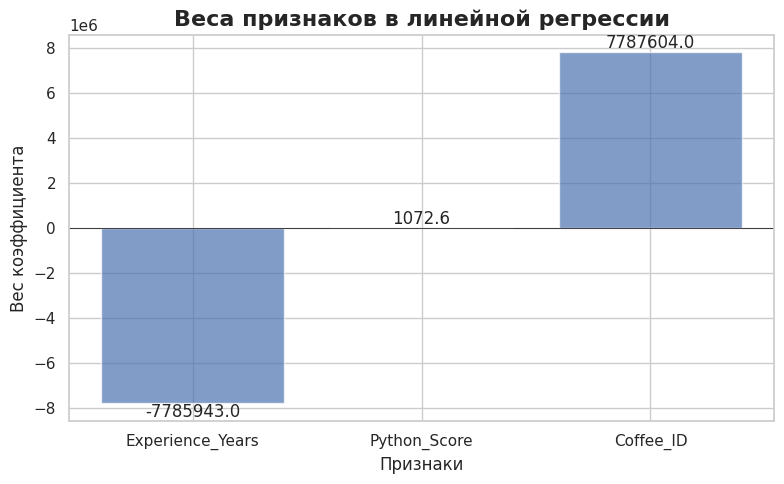

In [141]:
features = ['Experience_Years', 'Python_Score', 'Coffee_ID']
X = df[features]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Обучение LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# Оценка качества
r2_lr = r2_score(y_test, y_pred_lr)
print(f"R² на тестовой выборке - {r2_lr:.4f}")
print("\nКоэффициенты модели:")
for feature, coef in zip(features, lr_model.coef_):
    print(f"{feature}: {coef:.4f}")

# Визуализация
plt.figure(figsize=(8, 5))
bars = plt.bar(features, lr_model.coef_, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Веса признаков в линейной регрессии', fontsize=16, fontweight='bold')
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Вес коэффициента', fontsize=12)

for bar, coef in zip(bars, lr_model.coef_):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{coef:.1f}', ha='center', va='bottom' if coef > 0 else 'top')

plt.tight_layout()
plt.show()

R² на тестовой выборке - 0.8463, это говорит нам о том, что модель достаточно точна.


<Figure size 1200x1000 with 0 Axes>

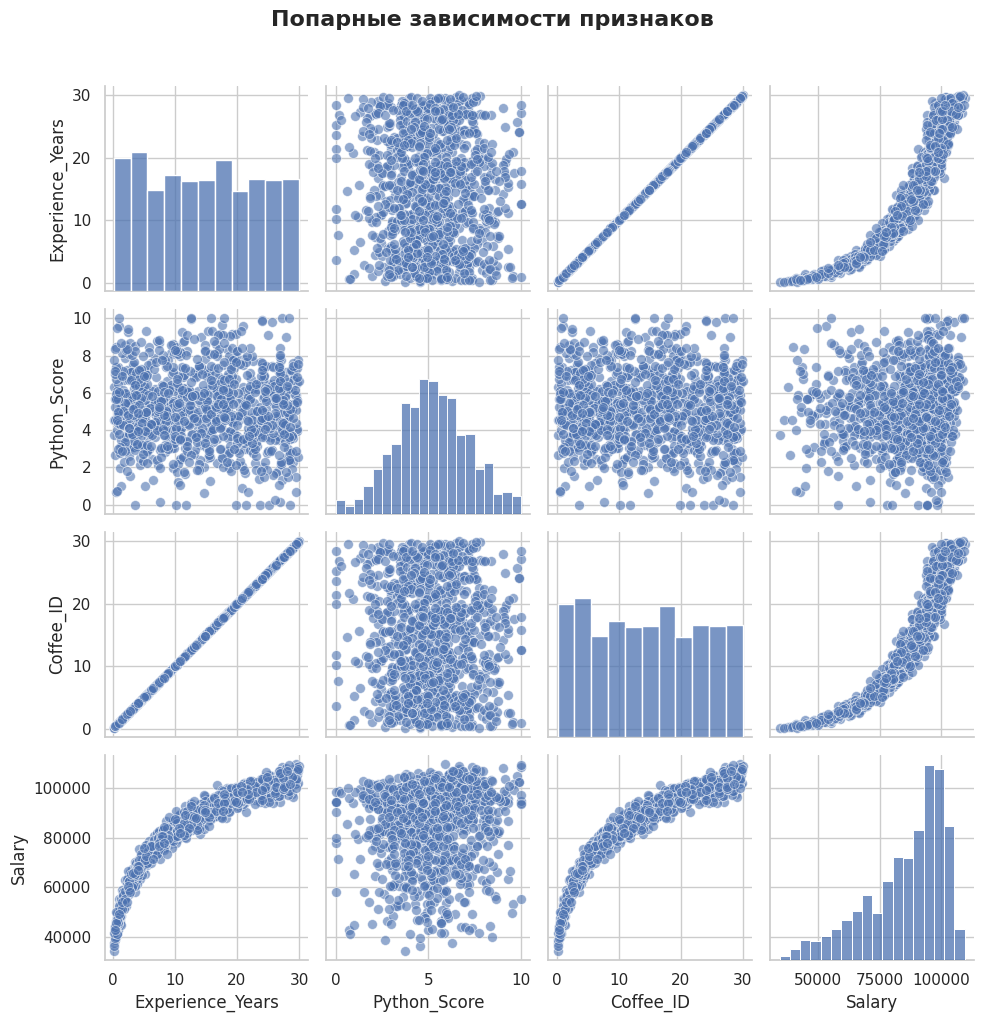

In [142]:
# Pairplot для визуализации всех попарных зависимостей
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 50})
plt.suptitle('Попарные зависимости признаков', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Почему веса Experience_Years и Coffee_ID ведут себя именно так? Можно ли использовать эти числа для объяснения логики зарплат в компании?**

Вес Experience_Years: больше опыта -> меньше зп

Вес Coffee_ID: больше опыта -> больше зп

Коэффициенты имеют огромные значения с противоположными знаками - сильная корреляции между признаками.

Нельзя использовать эти числа для объяснения логики зарплат в компании.

### 3.  **Нелинейный аудит**

In [143]:
# Без Coffee_ID
features_nc = ['Experience_Years', 'Python_Score']
X_nс = df[features_nc]
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_nс, y, test_size=0.2, random_state=42)

# Линейная регрессия без Coffee_ID
lr_nc = LinearRegression()
lr_nc.fit(X_train_nc, y_train_nc)
y_pred_lr_nc = lr_nc.predict(X_test_nc)
r2_lr_nc = r2_score(y_test_nc, y_pred_lr_nc)

# EBM модель
ebm = ExplainableBoostingRegressor(random_state=42, interactions=0)
ebm.fit(X_train_nc, y_train_nc)
y_pred_ebm = ebm.predict(X_test_nc)
r2_ebm = r2_score(y_test_nc, y_pred_ebm)

print(f"LinearRegression R²: {r2_lr_nc:.4f}")
print(f"EBM R²: {r2_ebm:.4f}")

# Визуализация EBM
ebm_global = ebm.explain_global()
show(ebm_global)

LinearRegression R²: 0.8463
EBM R²: 0.9867


Оценка R² показывает, что EBM точнее, чем линейная регрессия.

### 4.  **Визуализация**

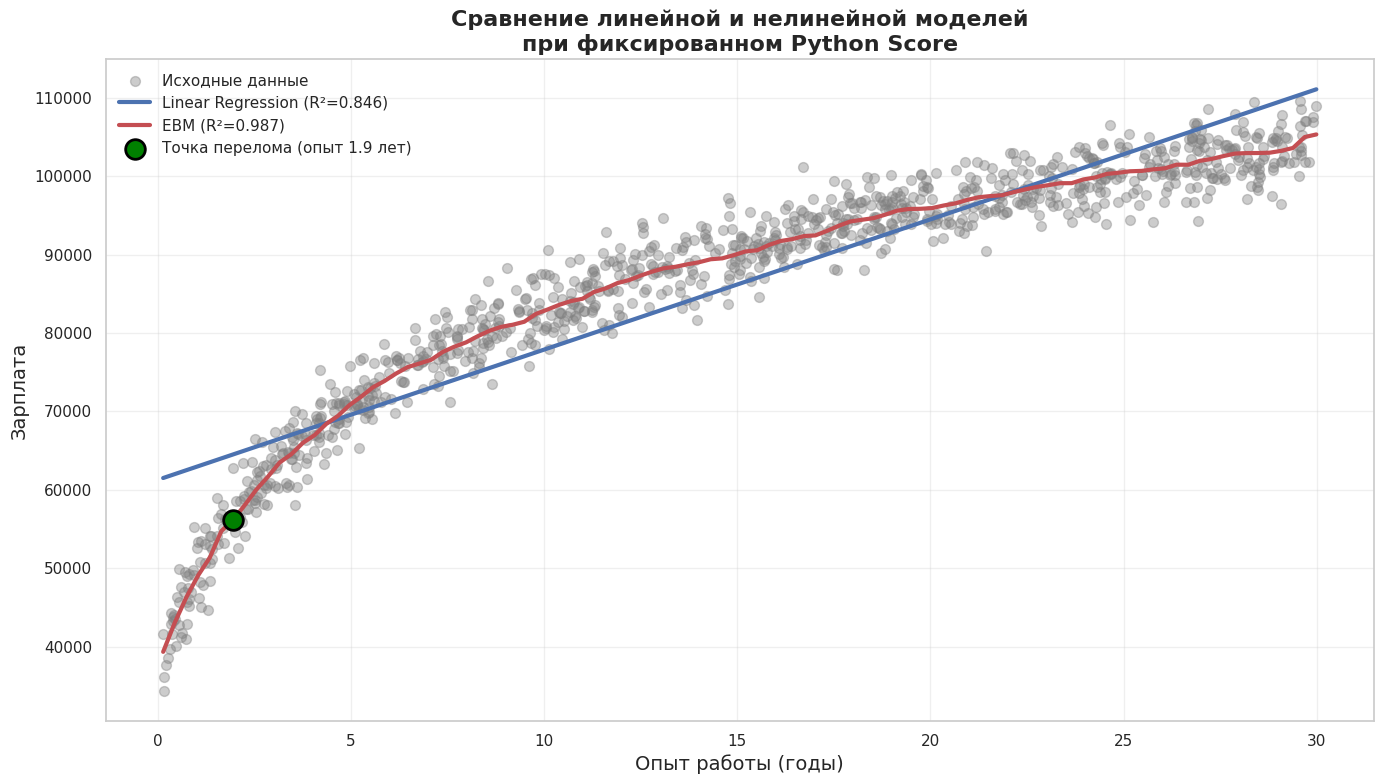

In [144]:
python_score_mean = df['Python_Score'].mean()
experience_range = np.linspace(df['Experience_Years'].min(),
                               df['Experience_Years'].max(), 100)
plot_data = pd.DataFrame({
    'Experience_Years': experience_range,
    'Python_Score': python_score_mean
})

lr_pred = lr_nc.predict(plot_data)
ebm_pred = ebm.predict(plot_data)

# Визуализация
plt.figure(figsize=(14, 8))

# Исходные данные
plt.scatter(df['Experience_Years'], df['Salary'],
           alpha=0.4, color='gray', s=50, label='Исходные данные')

# Линейная регрессия
plt.plot(experience_range, lr_pred, 'b-', linewidth=3,
         label=f'Linear Regression (R²={r2_lr_nc:.3f})')

# EBM
plt.plot(experience_range, ebm_pred, 'r-', linewidth=3,
         label=f'EBM (R²={r2_ebm:.3f})')

# Точка перелома для EBM
derivative = np.gradient(ebm_pred, experience_range)
break_point_idx = np.argmax(np.abs(derivative[1:] - derivative[:-1])) + 1
break_point_x = experience_range[break_point_idx]
break_point_y = ebm_pred[break_point_idx]

plt.scatter(break_point_x, break_point_y, color='green', s=200, zorder=5,
           marker='o', edgecolors='black', linewidth=2,
           label=f'Точка перелома (опыт {break_point_x:.1f} лет)')

plt.xlabel('Опыт работы (годы)', fontsize=14)
plt.ylabel('Зарплата', fontsize=14)
plt.title('Сравнение линейной и нелинейной моделей\nпри фиксированном Python Score',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Точка перелома находится примерно на опыте работы 1.9 лет.

Какая модель лучше описывает реальность и в чем заключается ошибка второй модели?

EBM лучше описывает реальность, так как улавливает нелинейные зависимости, более гибко подстраивается под данные.

Линейная модель предполагает постоянный прирост зарплаты с каждым годом опыта, но в реальности эффект от опыта может ускоряться или замедляться.

## Задание 2: Финтех-детектив (The Hidden Pattern)

### Легенда
Вы работаете в FinTech стартапе. Вам прислали «грязный» датасет с 15+ признаками (анкетные данные клиентов, социальные параметры, технические ID). Ваша задача — обучить самую точную, но при этом безопасную и интерпретируемую модель для оценки дохода.

### 1.  **Загрузка**

In [145]:
# Загружаем данные
df2 = pd.read_csv('Task_2.csv')
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User_ID         3000 non-null   int64  
 1   Age             3000 non-null   int64  
 2   Gender          3000 non-null   object 
 3   City            3000 non-null   object 
 4   Education       3000 non-null   object 
 5   Marital_Status  3000 non-null   object 
 6   Shoe_Size       3000 non-null   float64
 7   Height          3000 non-null   float64
 8   Zodiac          3000 non-null   object 
 9   Color           3000 non-null   object 
 10  Pets            3000 non-null   int64  
 11  Salary          3000 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 281.4+ KB


,User_ID,Age,Shoe_Size,Height,Pets,Salary
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,39.542667,39.974319,170.038916,2.014333,100455.182301
std,866.169729,11.571148,2.000533,9.926274,1.414966,24959.141935
min,0.000000,20.000000,33.109630,138.576884,0.000000,37900.046497
25%,749.750000,30.000000,38.628509,163.227852,1.000000,82435.634967
50%,1499.500000,40.000000,39.969006,170.132264,2.000000,98769.739312
75%,2249.250000,50.000000,41.332006,176.848559,3.000000,117215.756535
max,2999.000000,59.000000,47.217592,201.530070,4.000000,185244.103922


In [146]:
df2.head()

,User_ID,Age,Gender,City,Education,Marital_Status,Shoe_Size,Height,Zodiac,Color,Pets,Salary
0,45,40,M,Tokyo,PhD,Divorced,41.049559,173.669434,Leo,Blue,2,112341.922612
1,668,35,M,London,Master,Divorced,38.332265,176.865556,Sagittarius,Green,4,93439.035481
2,1650,52,M,NY,School,Married,39.000203,168.978529,Scorpio,Green,0,100613.339512
3,1247,54,M,Tokyo,School,Married,37.376580,170.917175,Scorpio,Green,3,121936.362834
4,18,59,F,NY,PhD,Single,39.269697,164.641542,Sagittarius,Blue,4,141688.826664


In [147]:
# Разделение признаки и целевею переменную
X2 = df2.drop('Salary', axis=1)
y2 = df2['Salary']

### 2.  **Слепое обучение**

In [148]:
# Обучение EBM модели
ebm = ExplainableBoostingRegressor(
    random_state=42,
    interactions=0,
    max_bins=128,
    max_leaves=3,
    learning_rate=0.1,
)

In [149]:
ebm.fit(X2, y2)

ExplainableBoostingRegressor(interactions=0, learning_rate=0.1, max_bins=128,
                             max_leaves=3)

In [150]:
ebm_global = ebm.explain_global()

# Визуализация
show(ebm_global)

### 3.  **Глобальный аудит**

Топ-5 самых важных признаков
     feature    importance
0    User_ID  12038.907388
1        Age  10223.767084
3       City   9408.120626
4  Education   7489.814930
6  Shoe_Size   1163.936370


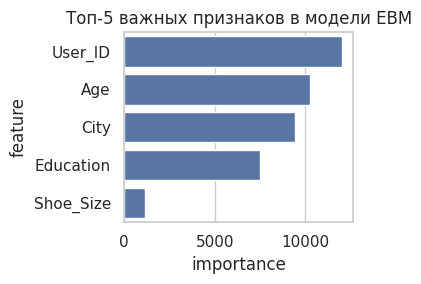

In [151]:
# Важность признаков
feature_names = ebm_global.data()['names']
feature_importance_scores = ebm_global.data()['scores']

# Создаем DataFrame с важностью признаков
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_scores
}).sort_values('importance', ascending=False)

print("Топ-5 самых важных признаков")
print(feature_importances.head(5))

# Визуализация
plt.figure(figsize=(4, 3))
sns.barplot(data=feature_importances.head(5), x='importance', y='feature')
plt.title('Топ-5 важных признаков в модели EBM')
plt.tight_layout()
plt.show()

Есть ли среди Топ-5 самых важных признаков по мнению модели признаки, которые кажутся вам «странными» или не имеющими отношения к доходу человека?

*   Shoe_Size





### 4.  **Визуальный анализ**

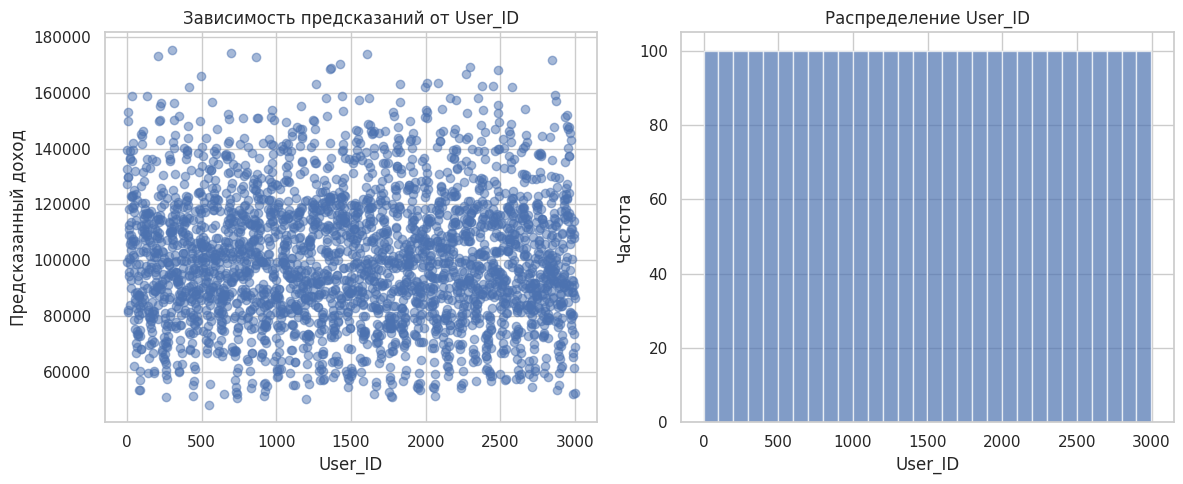

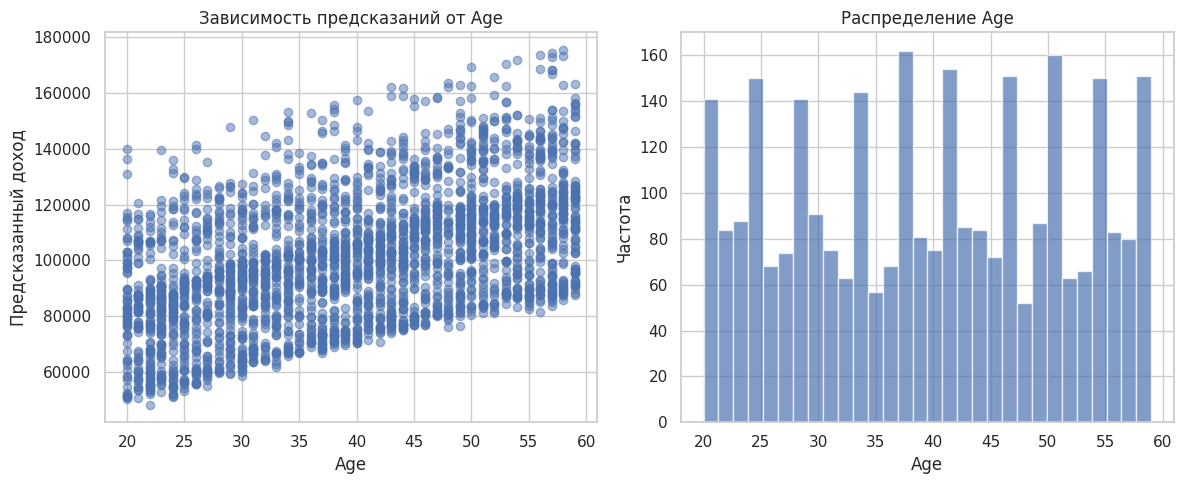

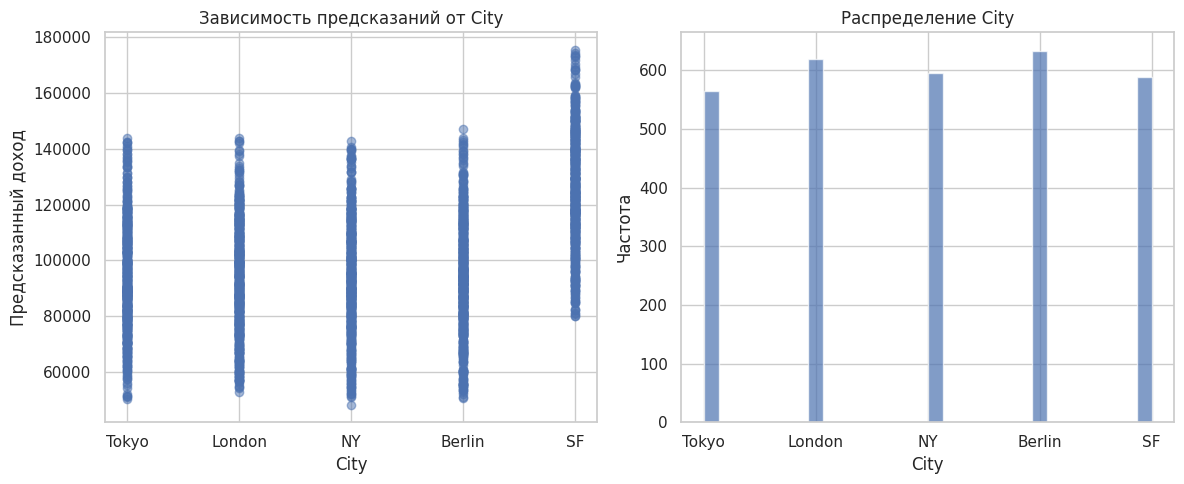

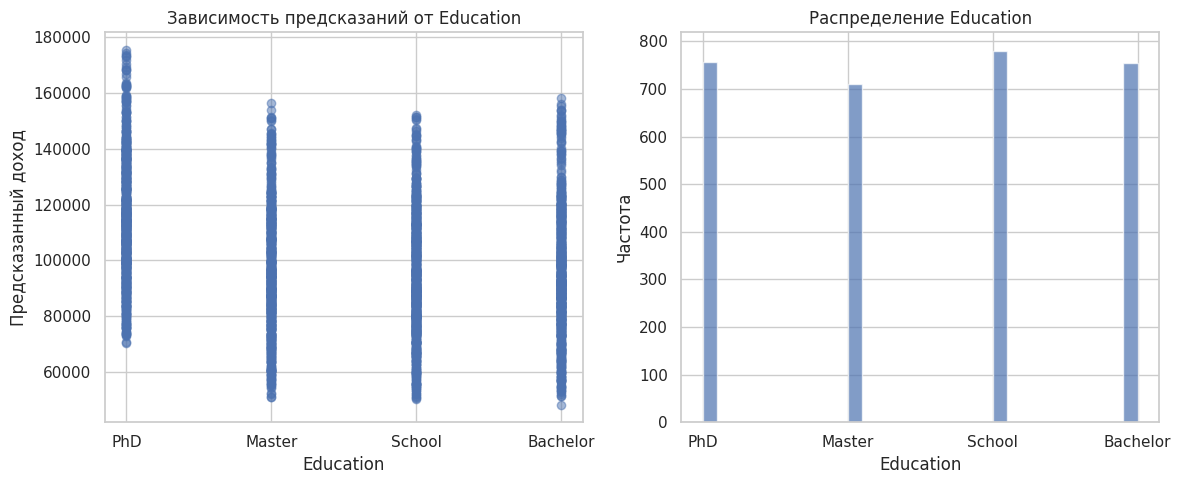

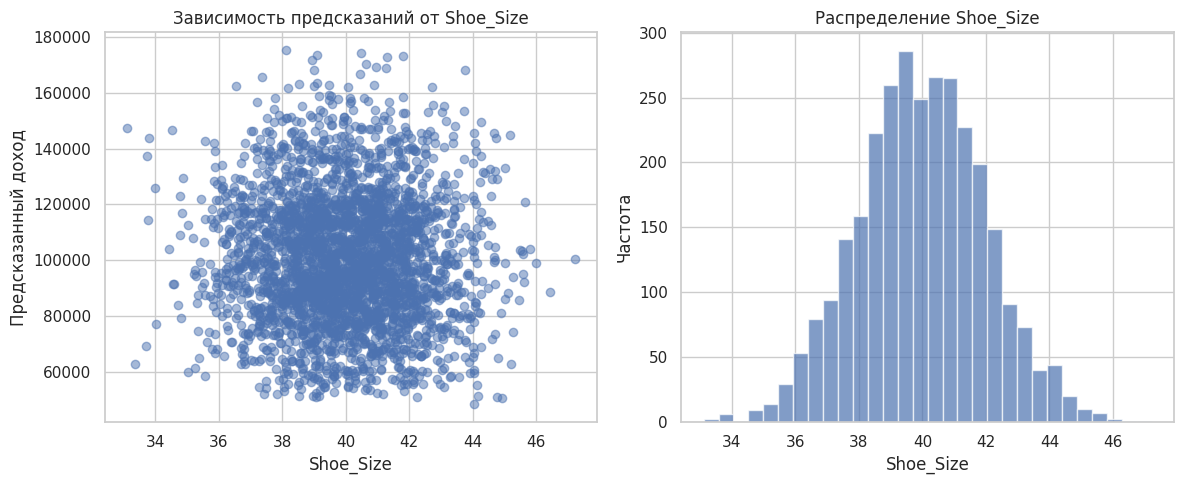

In [152]:
# Анализ топ-5 признаков
for feature in feature_importances.head(5)['feature'].values:
    X_temp = X2[[feature]].copy()
    y_pred = ebm.predict(X2)

    # Scatter plot
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X2[feature], y_pred, alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Предсказанный доход')
    plt.title(f'Зависимость предсказаний от {feature}')

    # Гистограмма распределения
    plt.subplot(1, 2, 2)
    plt.hist(X2[feature], bins=30, alpha=0.7)
    plt.xlabel(feature)
    plt.ylabel('Частота')
    plt.title(f'Распределение {feature}')

    plt.tight_layout()
    plt.show()

In [153]:
df2.head()

,User_ID,Age,Gender,City,Education,Marital_Status,Shoe_Size,Height,Zodiac,Color,Pets,Salary
0,45,40,M,Tokyo,PhD,Divorced,41.049559,173.669434,Leo,Blue,2,112341.922612
1,668,35,M,London,Master,Divorced,38.332265,176.865556,Sagittarius,Green,4,93439.035481
2,1650,52,M,NY,School,Married,39.000203,168.978529,Scorpio,Green,0,100613.339512
3,1247,54,M,Tokyo,School,Married,37.376580,170.917175,Scorpio,Green,3,121936.362834
4,18,59,F,NY,PhD,Single,39.269697,164.641542,Sagittarius,Blue,4,141688.826664


**Вопрос:** Как вы думаете, что именно произошло? Если вы оставите этот признак в модели и внедрите её в продакшен, что случится, когда придут новые клиенты?

Модель выявила ложную закономерность.
Также в реальности размер ноги не влияет на зарплату. Чаще всего размер ноги коррелирует, например, с полом и другими признаками, поэтому это надо исправить.

Если оставим этот признак, в дальнейшем он может сильно влиять на результат и точность предсказаний будет падать.

### 5.  **Исправление**

In [154]:
def evaluate_model(model, X, y):
    """Оценивает качество модели и возвращает метрики"""
    y_pred = model.predict(X)

    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")

    return {'mse': mse, 'mae': mae, 'rmse': rmse, 'r2': r2}

In [155]:
# Удаляем признак
print("Удаляем признак Shoe_Size")
X2_cleaned = X2.drop(columns=['Shoe_Size'])

# Обучение модели без Shoe_Size
ebm_cleaned = ExplainableBoostingRegressor(
    random_state=42,
    interactions=0,
    max_bins=128,
    max_leaves=3,
    learning_rate=0.1,
)
ebm_cleaned.fit(X2_cleaned, y2)

Удаляем признак Shoe_Size


ExplainableBoostingRegressor(interactions=0, learning_rate=0.1, max_bins=128,
                             max_leaves=3)

In [156]:
print("Исходная модель")
original_metrics = evaluate_model(ebm, X2, y2)

Исходная модель
MSE: 63219332.07
MAE: 6402.44
RMSE: 7951.06
R2 Score: 0.8985


In [157]:
# Оценка модели без Shoe_Size
print("Модель без признака Shoe_Size")
cleaned_metrics = evaluate_model(ebm_cleaned, X2_cleaned, y2)

Модель без признака Shoe_Size
MSE: 66218386.29
MAE: 6528.19
RMSE: 8137.47
R2 Score: 0.8937


Точность упала на 0.0048.